In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [10]:
#Filling null Value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df['Age']=df['Age'].fillna(df['Age'].median())

In [11]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

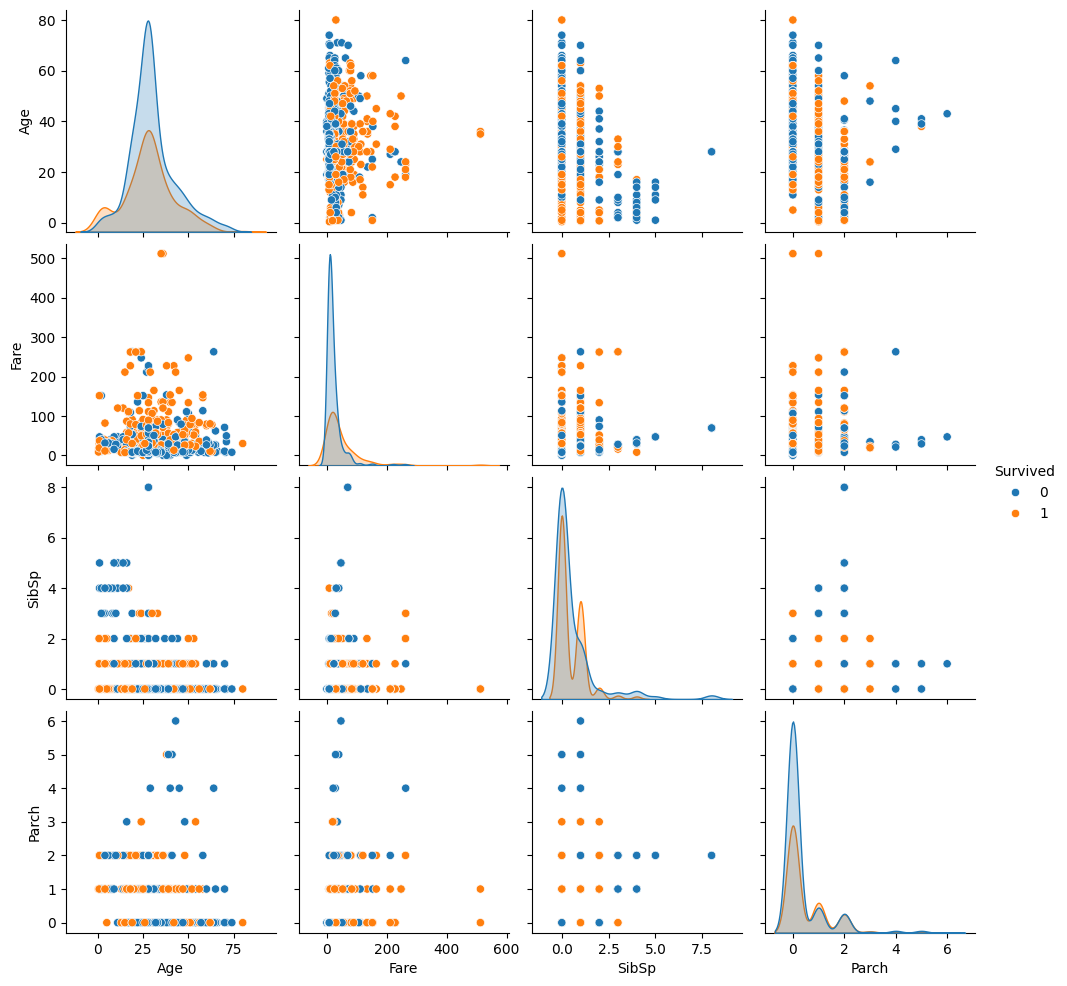

In [20]:
sns.pairplot(
    df[["Age","Fare","SibSp","Parch","Survived"]],
    hue="Survived"
)

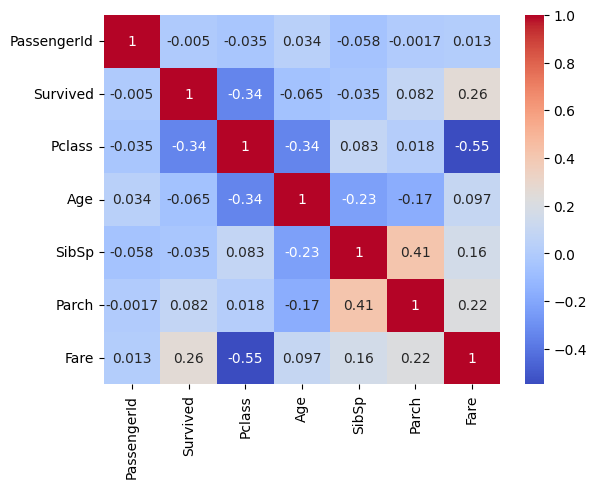

In [21]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

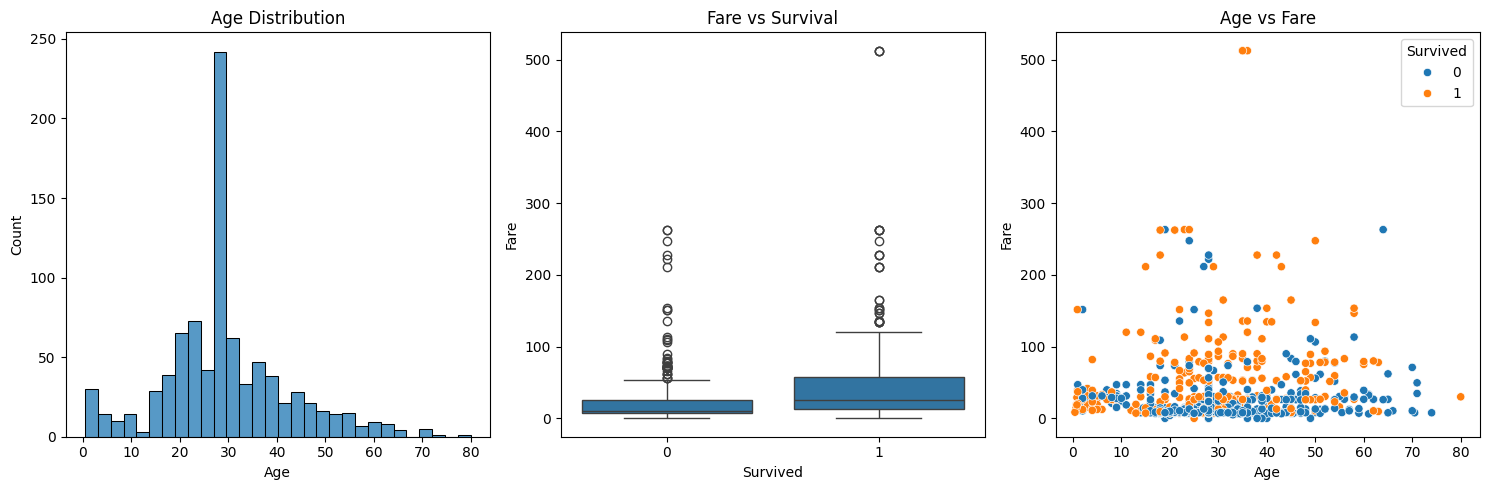

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram
sns.histplot(df["Age"], bins=30, ax=axes[0])
axes[0].set_title("Age Distribution")

# Box Plot
sns.boxplot(data=df, x="Survived", y="Fare", ax=axes[1])
axes[1].set_title("Fare vs Survival")

# Scatter Plot
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived",
    ax=axes[2]
)
axes[2].set_title("Age vs Fare")

plt.tight_layout()
plt.show()

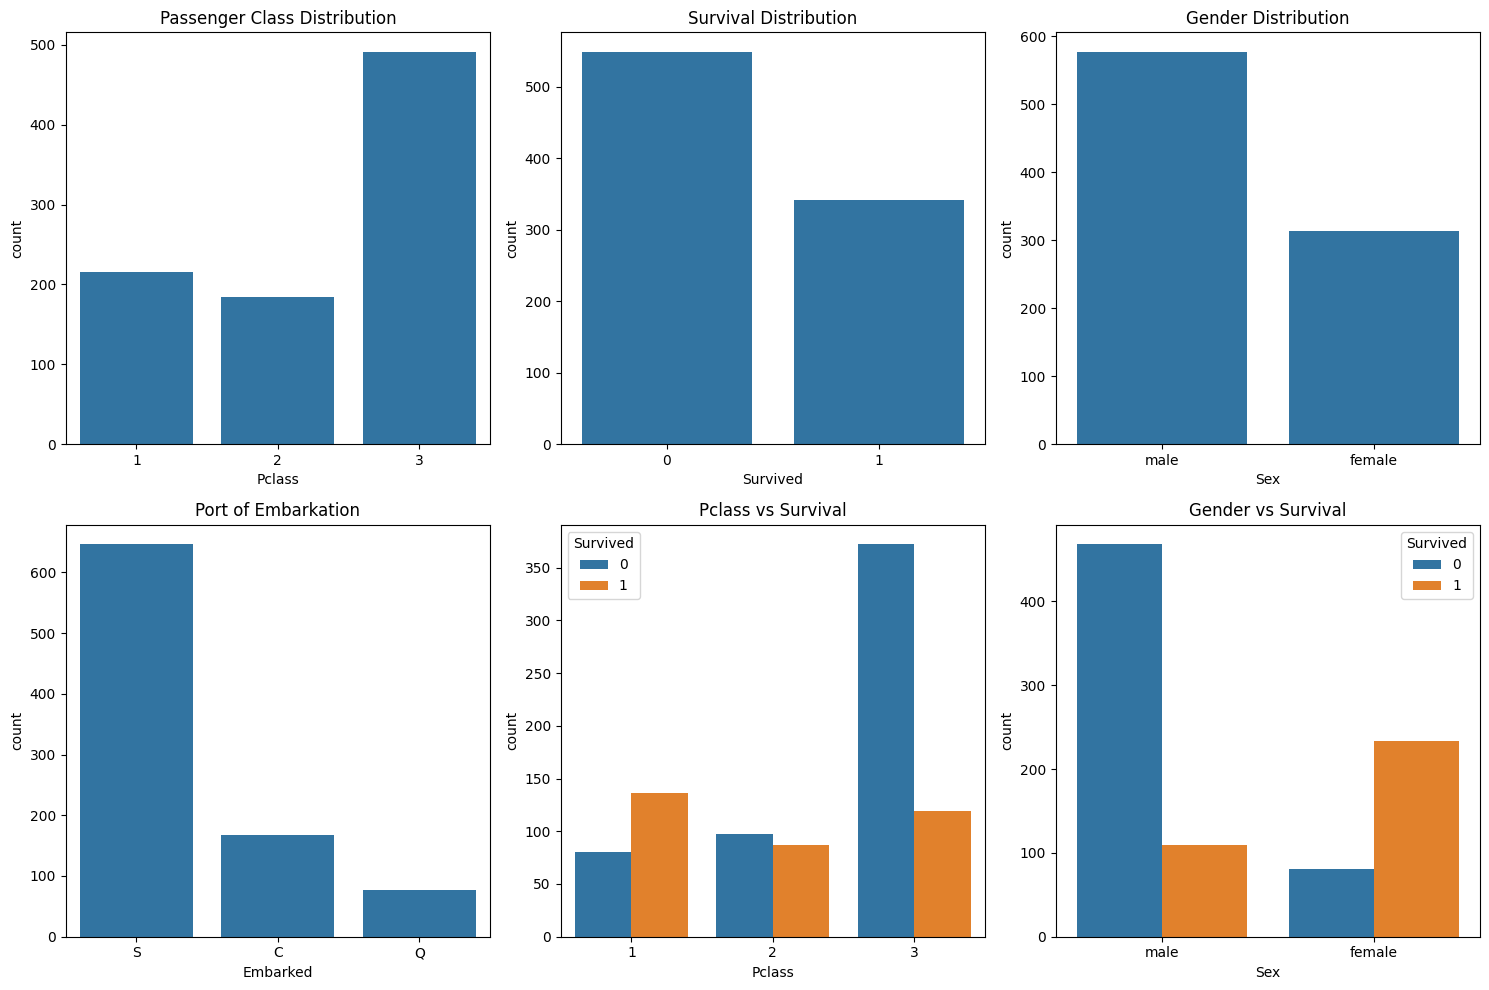

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Pclass Distribution
sns.countplot(data=df, x="Pclass", ax=axes[0, 0])
axes[0, 0].set_title("Passenger Class Distribution")

# Survived Distribution
sns.countplot(data=df, x="Survived", ax=axes[0, 1])
axes[0, 1].set_title("Survival Distribution")

# Sex Distribution
sns.countplot(data=df, x="Sex", ax=axes[0, 2])
axes[0, 2].set_title("Gender Distribution")

# Embarked Distribution
sns.countplot(data=df, x="Embarked", ax=axes[1, 0])
axes[1, 0].set_title("Port of Embarkation")

# Pclass vs Survived
sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[1, 1])
axes[1, 1].set_title("Pclass vs Survival")

# Sex vs Survived
sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[1, 2])
axes[1, 2].set_title("Gender vs Survival")

plt.tight_layout()
plt.show()

In [24]:
# Summary of each visual

print("=" * 60)
print("VISUALIZATION SUMMARIES")
print("=" * 60)

print("\n1. PASSENGER CLASS DISTRIBUTION")
print("   - Shows the count of passengers in each class (1st, 2nd, 3rd)")
print(f"   - Class distribution: {df['Pclass'].value_counts().sort_index().to_dict()}")

print("\n2. SURVIVAL DISTRIBUTION")
print("   - Shows the count of passengers who survived vs did not survive")
print(f"   - Survival counts: {df['Survived'].value_counts().to_dict()}")

print("\n3. GENDER DISTRIBUTION")
print("   - Shows the count of male vs female passengers")
print(f"   - Gender counts: {df['Sex'].value_counts().to_dict()}")

print("\n4. PORT OF EMBARKATION")
print("   - Shows the count of passengers embarking from each port (S, C, Q)")
print(f"   - Port counts: {df['Embarked'].value_counts().to_dict()}")

print("\n5. PCLASS VS SURVIVAL")
print("   - Shows survival rates across different passenger classes")
print("   - Higher class passengers had better survival rates")

print("\n6. GENDER VS SURVIVAL")
print("   - Shows survival rates by gender")
print(f"   - Female survival rate: {(df[df['Sex']=='female']['Survived'].sum() / len(df[df['Sex']=='female']) * 100):.1f}%")
print(f"   - Male survival rate: {(df[df['Sex']=='male']['Survived'].sum() / len(df[df['Sex']=='male']) * 100):.1f}%")

print("\n" + "=" * 60)

VISUALIZATION SUMMARIES

1. PASSENGER CLASS DISTRIBUTION
   - Shows the count of passengers in each class (1st, 2nd, 3rd)
   - Class distribution: {1: 216, 2: 184, 3: 491}

2. SURVIVAL DISTRIBUTION
   - Shows the count of passengers who survived vs did not survive
   - Survival counts: {0: 549, 1: 342}

3. GENDER DISTRIBUTION
   - Shows the count of male vs female passengers
   - Gender counts: {'male': 577, 'female': 314}

4. PORT OF EMBARKATION
   - Shows the count of passengers embarking from each port (S, C, Q)
   - Port counts: {'S': 646, 'C': 168, 'Q': 77}

5. PCLASS VS SURVIVAL
   - Shows survival rates across different passenger classes
   - Higher class passengers had better survival rates

6. GENDER VS SURVIVAL
   - Shows survival rates by gender
   - Female survival rate: 74.2%
   - Male survival rate: 18.9%

